In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import math

In [3]:
soccer_scores = pd.read_csv('../output/csvs/soccer_projII.csv')
soccer_scores

,Unnamed: 0,League,Season,Team,Sequence,n,n1,n2,k,k1,k2,c1,c2,c3
0,0,D1,2000,Bayern Munich,"[1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, ...",28,14,14,19,9,10,1.414208,1.430743,1.310616
1,1,D1,2000,Bochum,"[1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, ...",28,14,14,7,5,2,3.557103,4.870410,6.024096
2,2,D1,2000,Cottbus,"[0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, ...",31,16,15,12,6,6,1.540103,1.122188,1.461988
3,3,D1,2000,Dortmund,"[1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, ...",24,12,12,16,7,9,1.221184,2.446390,1.117318
4,4,D1,2000,Ein Frankfurt,"[1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, ...",29,15,14,10,6,4,2.278359,1.874137,2.557545
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1433,1433,SP1,2024,Sociedad,"[0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, ...",31,16,15,13,8,5,2.899686,2.753724,3.802281
1434,1434,SP1,2024,Valencia,"[0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, ...",25,13,12,11,3,8,1.031319,34.116240,1.005025
1435,1435,SP1,2024,Valladolid,"[1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, ...",34,17,17,4,4,0,8.396151,24.207011,21.598272
1436,1436,SP1,2024,Vallecano,"[1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, ...",25,13,12,13,7,6,1.793021,1.169291,1.672241


In [5]:
soccer_scores['League'] = soccer_scores['League'].replace("E0", "Premier_League")
soccer_scores['League'] = soccer_scores['League'].replace("D1", "Bundesliga")
soccer_scores['League'] = soccer_scores['League'].replace("SP1", "La_Liga")

In [7]:
soccer_scores['Team_Name'] = soccer_scores['Season'].astype(str) + ' ' + soccer_scores['Team']
soccer_scores

,Unnamed: 0,League,Season,Team,Sequence,n,n1,n2,k,k1,k2,c1,c2,c3,Team_Name
0,0,Bundesliga,2000,Bayern Munich,"[1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, ...",28,14,14,19,9,10,1.414208,1.430743,1.310616,2000 Bayern Munich
1,1,Bundesliga,2000,Bochum,"[1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, ...",28,14,14,7,5,2,3.557103,4.870410,6.024096,2000 Bochum
2,2,Bundesliga,2000,Cottbus,"[0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, ...",31,16,15,12,6,6,1.540103,1.122188,1.461988,2000 Cottbus
3,3,Bundesliga,2000,Dortmund,"[1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, ...",24,12,12,16,7,9,1.221184,2.446390,1.117318,2000 Dortmund
4,4,Bundesliga,2000,Ein Frankfurt,"[1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, ...",29,15,14,10,6,4,2.278359,1.874137,2.557545,2000 Ein Frankfurt
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1433,1433,La_Liga,2024,Sociedad,"[0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, ...",31,16,15,13,8,5,2.899686,2.753724,3.802281,2024 Sociedad
1434,1434,La_Liga,2024,Valencia,"[0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, ...",25,13,12,11,3,8,1.031319,34.116240,1.005025,2024 Valencia
1435,1435,La_Liga,2024,Valladolid,"[1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, ...",34,17,17,4,4,0,8.396151,24.207011,21.598272,2024 Valladolid
1436,1436,La_Liga,2024,Vallecano,"[1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, ...",25,13,12,13,7,6,1.793021,1.169291,1.672241,2024 Vallecano


In [9]:
us_league_scores = pd.read_csv('../output/csvs/us_leagues_projII.csv')
us_league_scores

,Unnamed: 0,League,Season,Team,Sequence,n,n1,n2,k,k1,k2,c1,c2,c3
0,0,NBA,2015,Orlando Magic,"[0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, ...",82,41,41,35,15,20,1.207136,3.705717,1.106195
1,1,NBA,2015,Houston Rockets,"[1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, ...",82,41,41,41,20,21,1.606721,1.207999,1.531394
2,2,NBA,2015,Oklahoma City Thunder,"[0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, ...",82,41,41,55,26,29,1.345656,2.053641,1.207729
3,3,NBA,2015,Sacramento Kings,"[0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, ...",82,41,41,33,15,18,1.351914,1.978912,1.228501
4,4,NBA,2015,Utah Jazz,"[0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, ...",82,41,41,40,22,18,3.122133,2.610411,4.115226
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3494,3494,NBA,1991,Boston Celtics,"[1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, ...",82,41,41,51,26,25,2.021358,1.215747,2.079002
3495,3495,NBA,1991,Los Angeles Lakers,"[1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, ...",82,41,41,43,18,25,1.117279,8.020818,1.042753
3496,3496,NBA,1991,Denver Nuggets,"[0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, ...",82,41,41,24,7,17,1.033851,66.410418,1.003009
3497,3497,NBA,1991,Dallas Mavericks,"[1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, ...",82,41,41,22,9,13,1.230567,3.078505,1.138952


# 1. Most extreme Collapses

## Soccer League

In [13]:
soccer_scores['log_c1'] = np.log(soccer_scores['c1'])
soccer_scores['log_c2'] = np.log(soccer_scores['c2'])
soccer_scores['log_c3'] = np.log(soccer_scores['c3'])

soccer_scores

,Unnamed: 0,League,Season,Team,Sequence,n,n1,n2,k,k1,k2,c1,c2,c3,Team_Name,log_c1,log_c2,log_c3
0,0,Bundesliga,2000,Bayern Munich,"[1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, ...",28,14,14,19,9,10,1.414208,1.430743,1.310616,2000 Bayern Munich,0.346570,0.358194,0.270497
1,1,Bundesliga,2000,Bochum,"[1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, ...",28,14,14,7,5,2,3.557103,4.870410,6.024096,2000 Bochum,1.268947,1.583178,1.795767
2,2,Bundesliga,2000,Cottbus,"[0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, ...",31,16,15,12,6,6,1.540103,1.122188,1.461988,2000 Cottbus,0.431849,0.115280,0.379797
3,3,Bundesliga,2000,Dortmund,"[1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, ...",24,12,12,16,7,9,1.221184,2.446390,1.117318,2000 Dortmund,0.199821,0.894614,0.110932
4,4,Bundesliga,2000,Ein Frankfurt,"[1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, ...",29,15,14,10,6,4,2.278359,1.874137,2.557545,2000 Ein Frankfurt,0.823455,0.628148,0.939048
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1433,1433,La_Liga,2024,Sociedad,"[0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, ...",31,16,15,13,8,5,2.899686,2.753724,3.802281,2024 Sociedad,1.064602,1.012954,1.335601
1434,1434,La_Liga,2024,Valencia,"[0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, ...",25,13,12,11,3,8,1.031319,34.116240,1.005025,2024 Valencia,0.030838,3.529774,0.005013
1435,1435,La_Liga,2024,Valladolid,"[1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, ...",34,17,17,4,4,0,8.396151,24.207011,21.598272,2024 Valladolid,2.127773,3.186642,3.072613
1436,1436,La_Liga,2024,Vallecano,"[1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, ...",25,13,12,13,7,6,1.793021,1.169291,1.672241,2024 Vallecano,0.583902,0.156398,0.514165


In [15]:
top20_c1 = soccer_scores.nlargest(20, "log_c1")[["Season", "League", "Team_Name", "log_c1"]]
top20_c2 = soccer_scores.nlargest(20, "log_c2")[["Season", "League", "Team_Name", "log_c2"]]
top20_c3 = soccer_scores.nlargest(20, "log_c3")[["Season", "League", "Team_Name", "log_c3"]]

top20_c1

,Season,League,Team_Name,log_c1
356,2019,Bundesliga,2019 Schalke 04,3.633475
1240,2015,La_Liga,2015 Eibar,3.111365
292,2016,Bundesliga,2016 Ein Frankfurt,3.022601
755,2015,Premier_League,2015 Crystal Palace,2.903254
1376,2021,La_Liga,2021 Vallecano,2.903254
1121,2009,La_Liga,2009 La Coruna,2.894519
1080,2007,La_Liga,2007 Espanol,2.736068
618,2008,Premier_League,2008 Hull,2.700427
868,2020,Premier_League,2020 Southampton,2.678658
172,2009,Bundesliga,2009 Leverkusen,2.549421


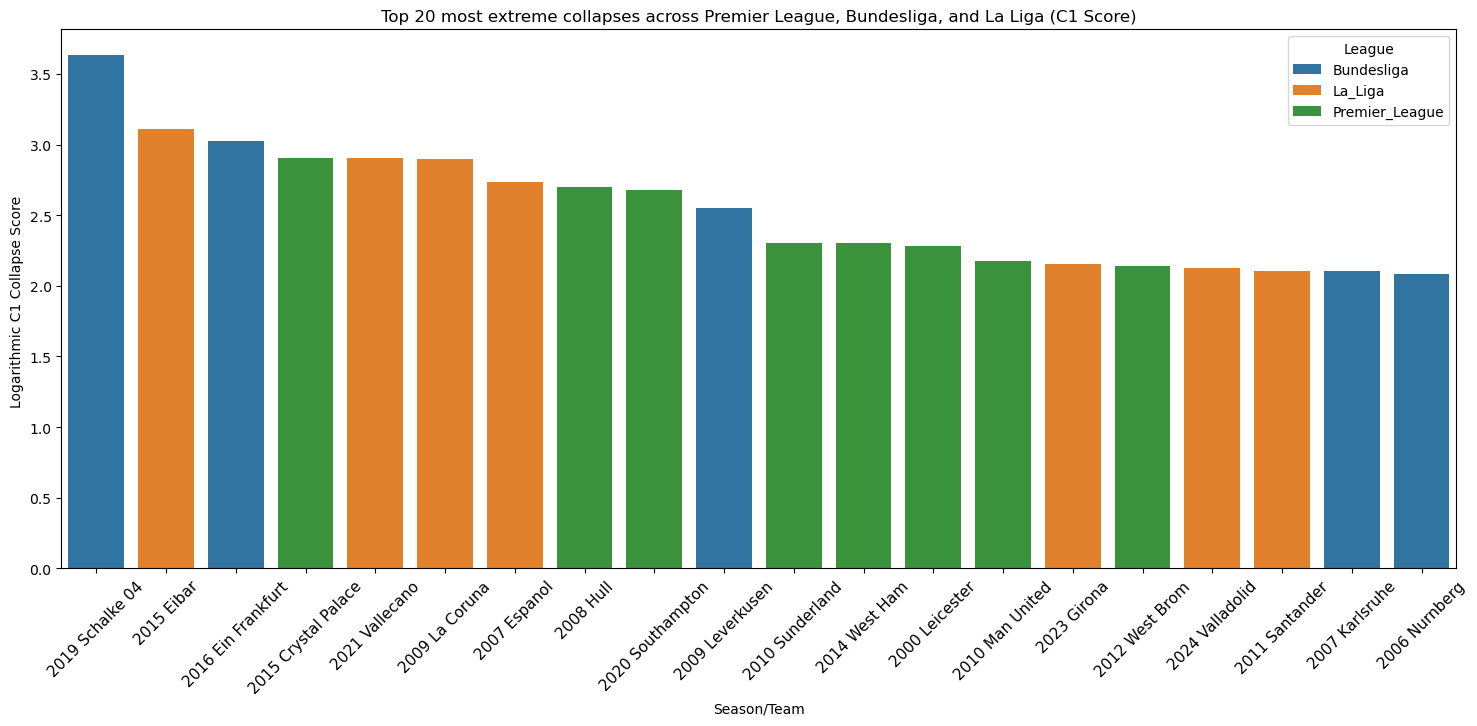

In [17]:
plt.figure(figsize=(18,7))

sns.barplot(x=top20_c1['Team_Name'], y = top20_c1['log_c1'], palette = 'tab10', hue = top20_c1['League'])
plt.title('Top 20 most extreme collapses across Premier League, Bundesliga, and La Liga (C1 Score)')
plt.xlabel('Season/Team')
plt.ylabel('Logarithmic C1 Collapse Score ')
plt.xticks(rotation=45, fontsize=11)
plt.show()

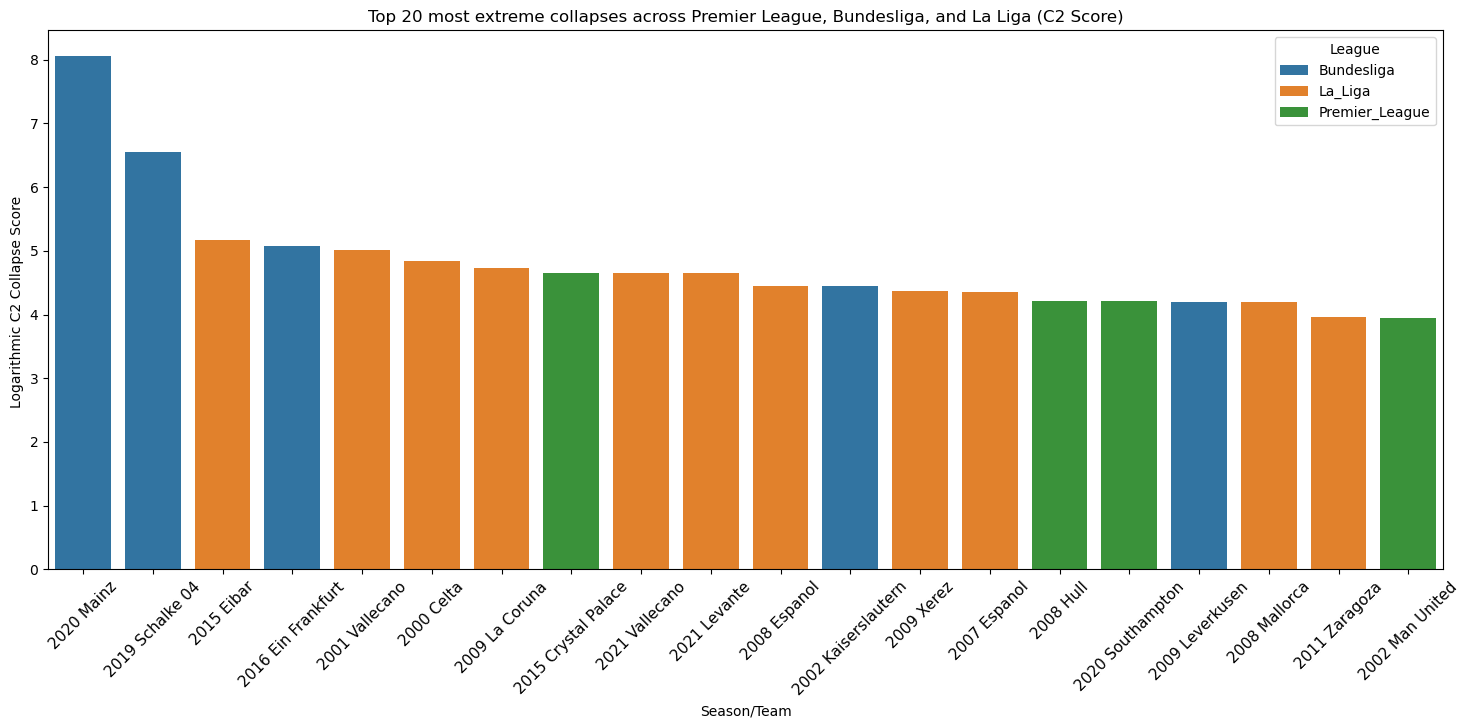

In [19]:
plt.figure(figsize=(18,7))

sns.barplot(x=top20_c2['Team_Name'], y = top20_c2['log_c2'], palette = 'tab10', hue = top20_c2['League'])
plt.title('Top 20 most extreme collapses across Premier League, Bundesliga, and La Liga (C2 Score)')
plt.xlabel('Season/Team')
plt.ylabel('Logarithmic C2 Collapse Score ')
plt.xticks(rotation=45, fontsize=11)
plt.show()

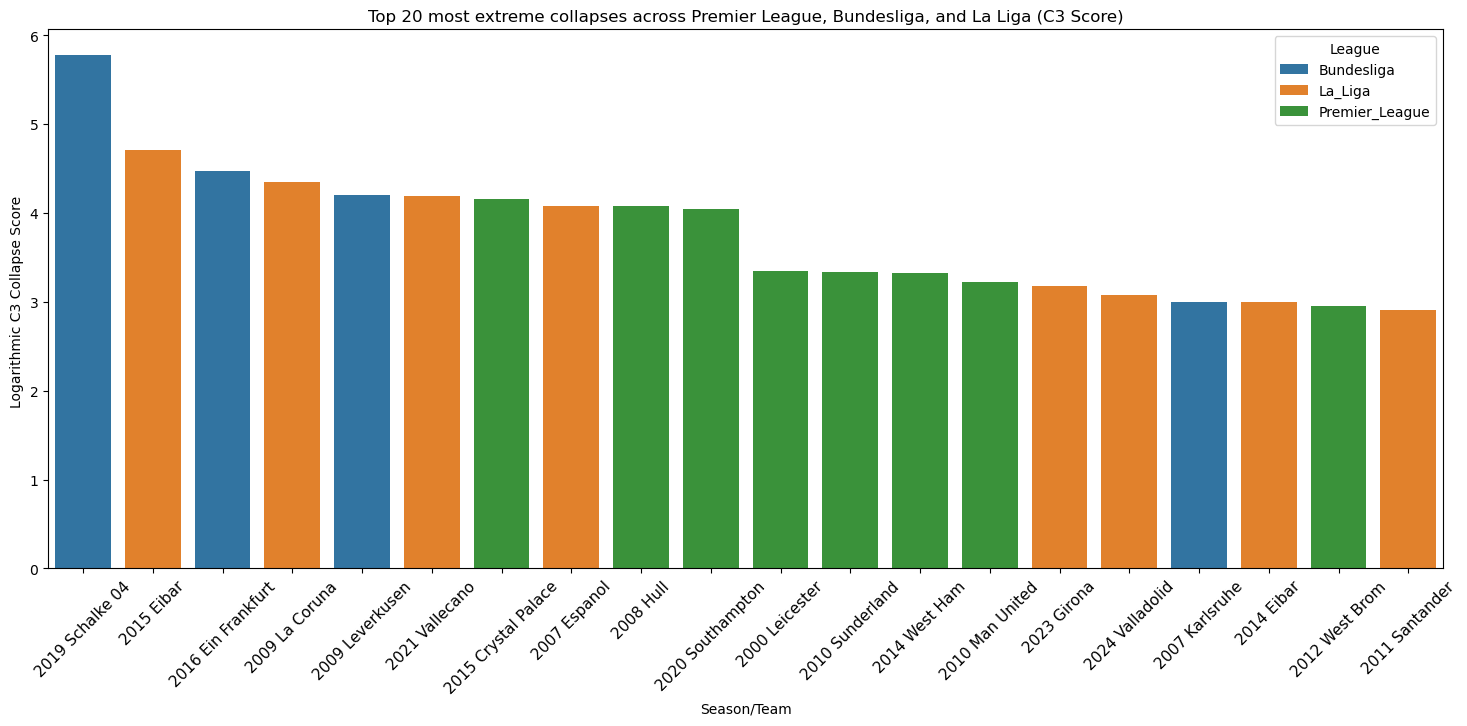

In [20]:
plt.figure(figsize=(18,7))

sns.barplot(x=top20_c3['Team_Name'], y = top20_c3['log_c3'], palette = 'tab10', hue = top20_c3['League'])
plt.title('Top 20 most extreme collapses across Premier League, Bundesliga, and La Liga (C3 Score)')
plt.xlabel('Season/Team')
plt.ylabel('Logarithmic C3 Collapse Score ')
plt.xticks(rotation=45, fontsize=11)
plt.show()

## US Leagues

In [24]:
us_league_scores['log_c1'] = us_league_scores.apply(lambda row: math.log(row['c1']), axis  = 1)
us_league_scores['log_c2'] = us_league_scores.apply(lambda row: math.log(row['c2']), axis  = 1)
us_league_scores['log_c3'] = us_league_scores.apply(lambda row: math.log(row['c3']), axis  = 1)

us_league_scores['formatted_team_name'] = us_league_scores.apply(lambda row: str(row['Season']) + ' ' + row['Team'], axis = 1)

us_league_scores['color'] = us_league_scores.apply(lambda row: "orange" if row['League'] == 'NBA' else 'blue', axis = 1)

In [26]:
us_league_scores

,Unnamed: 0,League,Season,Team,Sequence,n,n1,n2,k,k1,k2,c1,c2,c3,log_c1,log_c2,log_c3,formatted_team_name,color
0,0,NBA,2015,Orlando Magic,"[0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, ...",82,41,41,35,15,20,1.207136,3.705717,1.106195,0.188250,1.309877,0.100926,2015 Orlando Magic,orange
1,1,NBA,2015,Houston Rockets,"[1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, ...",82,41,41,41,20,21,1.606721,1.207999,1.531394,0.474195,0.188966,0.426178,2015 Houston Rockets,orange
2,2,NBA,2015,Oklahoma City Thunder,"[0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, ...",82,41,41,55,26,29,1.345656,2.053641,1.207729,0.296882,0.719614,0.188742,2015 Oklahoma City Thunder,orange
3,3,NBA,2015,Sacramento Kings,"[0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, ...",82,41,41,33,15,18,1.351914,1.978912,1.228501,0.301521,0.682547,0.205795,2015 Sacramento Kings,orange
4,4,NBA,2015,Utah Jazz,"[0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, ...",82,41,41,40,22,18,3.122133,2.610411,4.115226,1.138516,0.959508,1.414694,2015 Utah Jazz,orange
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3494,3494,NBA,1991,Boston Celtics,"[1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, ...",82,41,41,51,26,25,2.021358,1.215747,2.079002,0.703770,0.195359,0.731888,1991 Boston Celtics,orange
3495,3495,NBA,1991,Los Angeles Lakers,"[1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, ...",82,41,41,43,18,25,1.117279,8.020818,1.042753,0.110896,2.082040,0.041864,1991 Los Angeles Lakers,orange
3496,3496,NBA,1991,Denver Nuggets,"[0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, ...",82,41,41,24,7,17,1.033851,66.410418,1.003009,0.033291,4.195854,0.003005,1991 Denver Nuggets,orange
3497,3497,NBA,1991,Dallas Mavericks,"[1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, ...",82,41,41,22,9,13,1.230567,3.078505,1.138952,0.207475,1.124444,0.130109,1991 Dallas Mavericks,orange


In [28]:
us_top20_c1 = us_league_scores.nlargest(20, "log_c1")[["Season", "League", "formatted_team_name", "log_c1"]]
us_top20_c2 = us_league_scores.nlargest(20, "log_c2")[["Season", "League", "formatted_team_name", "log_c2"]]
us_top20_c3 = us_league_scores.nlargest(20, "log_c3")[["Season", "League", "formatted_team_name", "log_c3"]]

us_top20_c1

,Season,League,formatted_team_name,log_c1
2397,2016,NBA,2016 Miami Heat,6.136720
312,1943,MLB,1943 Philadelphia Athletics,4.474926
945,1977,MLB,1977 Chicago Cubs,4.356189
3439,2004,NBA,2004 Denver Nuggets,4.292950
413,1949,MLB,1949 Washington Senators,4.096913
3359,2017,NBA,2017 Utah Jazz,3.891223
1691,2004,MLB,2004 Milwaukee Brewers,3.832378
1735,2005,MLB,2005 Washington Nationals,3.798058
849,1973,MLB,1973 Chicago Cubs,3.715958
904,1975,MLB,1975 Milwaukee Brewers,3.633267


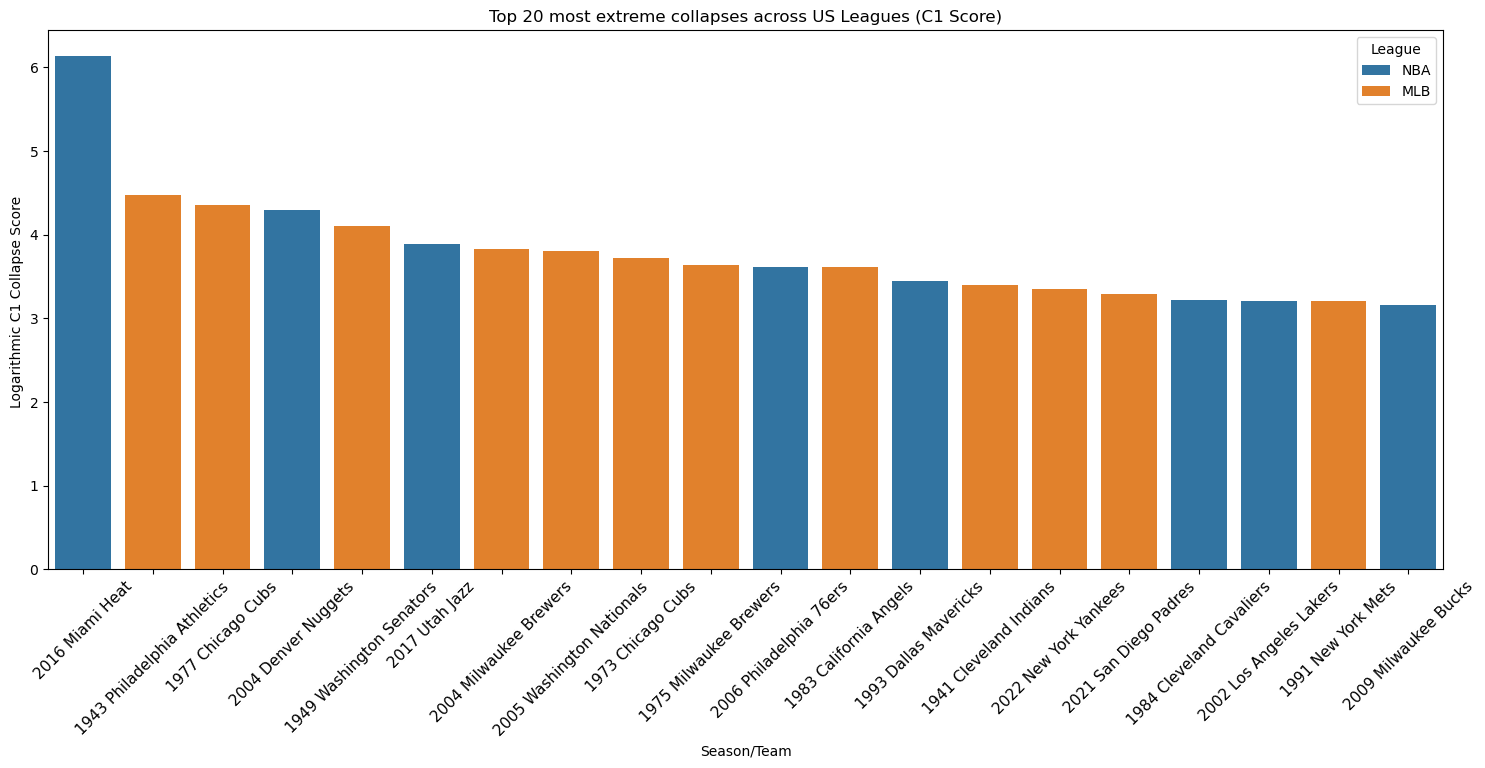

In [30]:
plt.figure(figsize=(18,7))

sns.barplot(x=us_top20_c1['formatted_team_name'], y = us_top20_c1['log_c1'], palette = 'tab10', hue = us_top20_c1['League'])
plt.title('Top 20 most extreme collapses across US Leagues (C1 Score)')
plt.xlabel('Season/Team')
plt.ylabel('Logarithmic C1 Collapse Score ')
plt.xticks(rotation=45, fontsize=11)
plt.show()

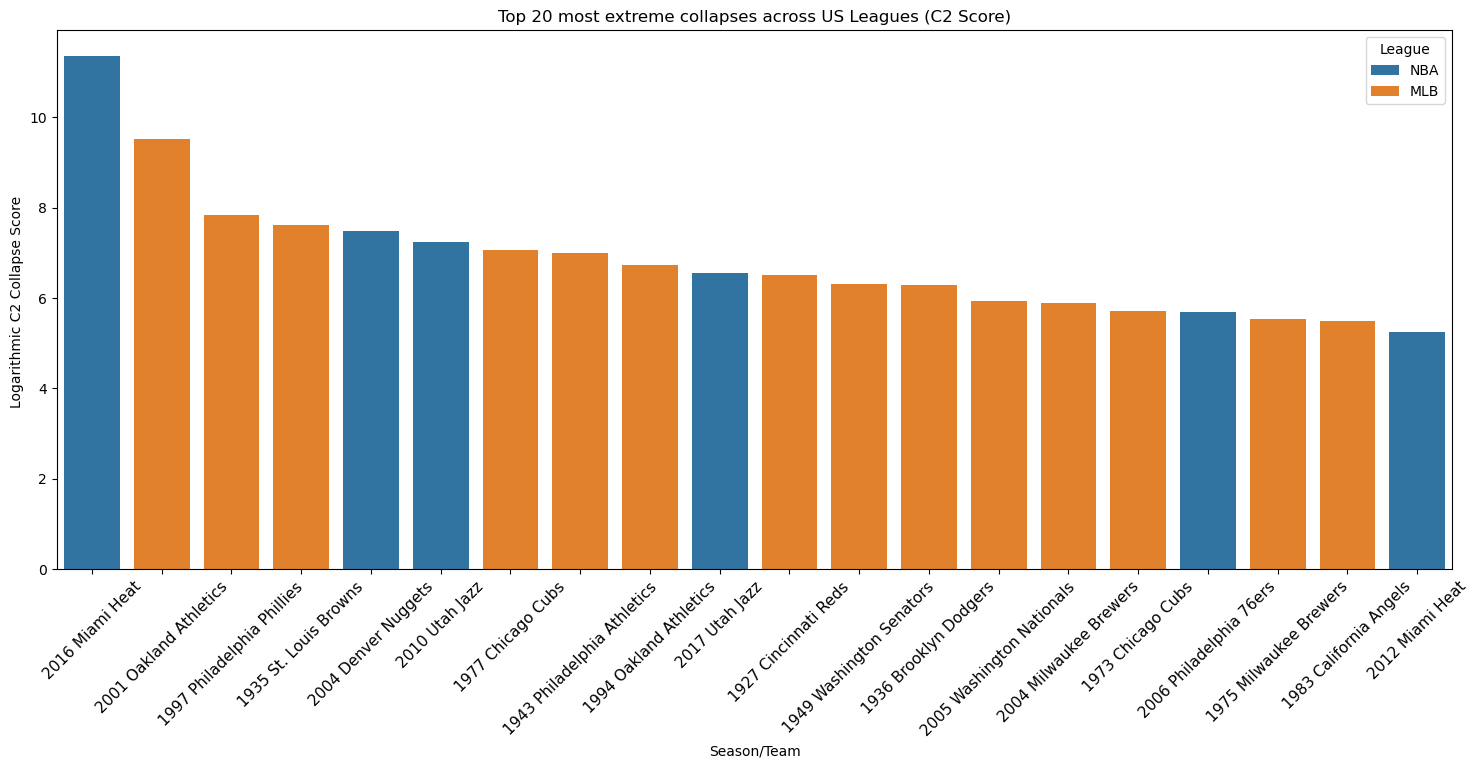

In [32]:
plt.figure(figsize=(18,7))

sns.barplot(x=us_top20_c2['formatted_team_name'], y = us_top20_c2['log_c2'], palette = 'tab10', hue = us_top20_c2['League'])
plt.title('Top 20 most extreme collapses across US Leagues (C2 Score)')
plt.xlabel('Season/Team')
plt.ylabel('Logarithmic C2 Collapse Score ')
plt.xticks(rotation=45, fontsize=11)
plt.show()

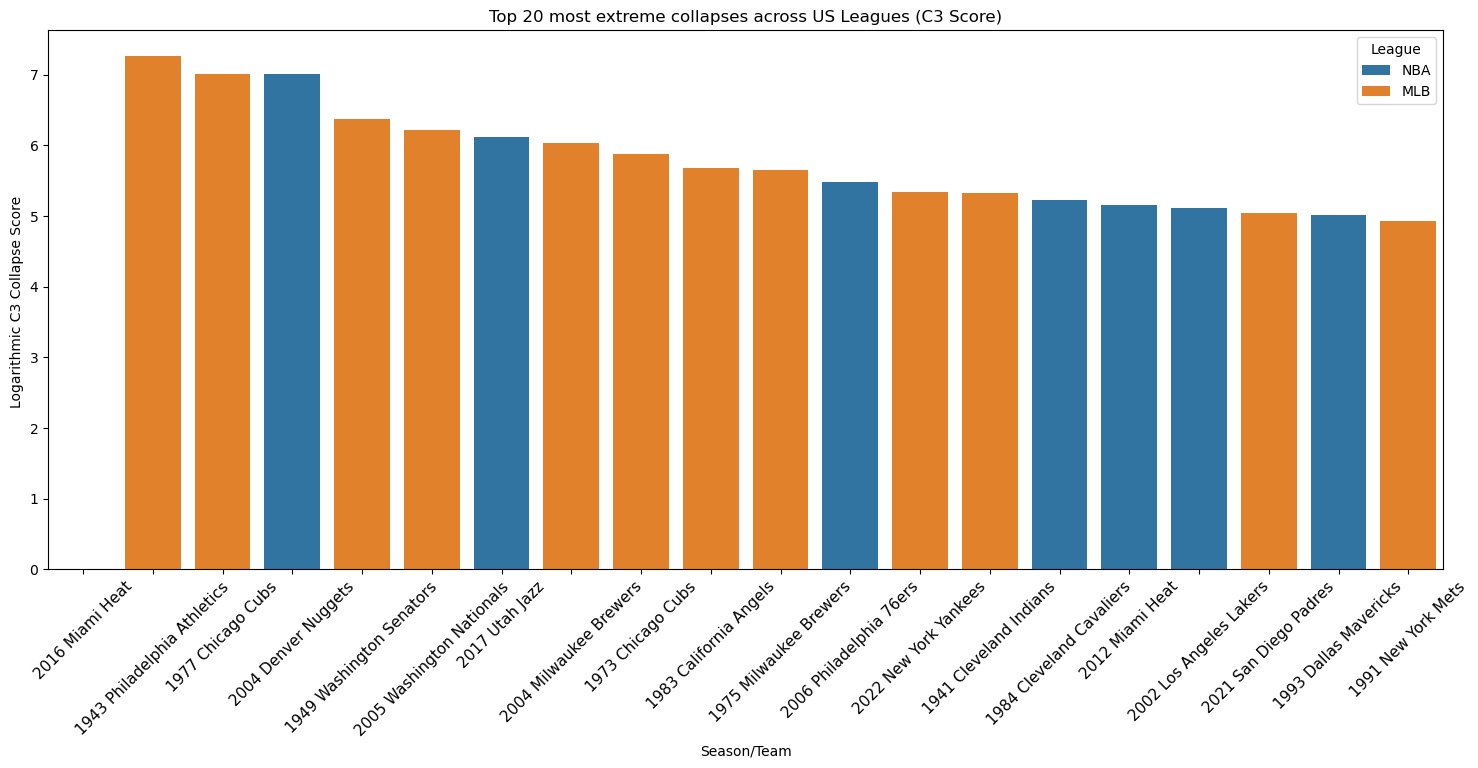

In [34]:
plt.figure(figsize=(18,7))

sns.barplot(x=us_top20_c3['formatted_team_name'], y = us_top20_c3['log_c3'], palette = 'tab10', hue = us_top20_c3['League'])
plt.title('Top 20 most extreme collapses across US Leagues (C3 Score)')
plt.xlabel('Season/Team')
plt.ylabel('Logarithmic C3 Collapse Score ')
plt.xticks(rotation=45, fontsize=11)
plt.show()

## US Leagues and Soccer Leagues Combined

In [21]:
soccer_scores

,Unnamed: 0,League,Season,Team,Sequence,n,n1,n2,k,k1,k2,c1,c2,c3,Team_Name,log_c1,log_c2,log_c3
0,0,Bundesliga,2000,Bayern Munich,"[1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, ...",28,14,14,19,9,10,1.414208,1.430743,1.310616,2000 Bayern Munich,0.346570,0.358194,0.270497
1,1,Bundesliga,2000,Bochum,"[1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, ...",28,14,14,7,5,2,3.557103,4.870410,6.024096,2000 Bochum,1.268947,1.583178,1.795767
2,2,Bundesliga,2000,Cottbus,"[0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, ...",31,16,15,12,6,6,1.540103,1.122188,1.461988,2000 Cottbus,0.431849,0.115280,0.379797
3,3,Bundesliga,2000,Dortmund,"[1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, ...",24,12,12,16,7,9,1.221184,2.446390,1.117318,2000 Dortmund,0.199821,0.894614,0.110932
4,4,Bundesliga,2000,Ein Frankfurt,"[1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, ...",29,15,14,10,6,4,2.278359,1.874137,2.557545,2000 Ein Frankfurt,0.823455,0.628148,0.939048
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1433,1433,La_Liga,2024,Sociedad,"[0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, ...",31,16,15,13,8,5,2.899686,2.753724,3.802281,2024 Sociedad,1.064602,1.012954,1.335601
1434,1434,La_Liga,2024,Valencia,"[0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, ...",25,13,12,11,3,8,1.031319,34.116240,1.005025,2024 Valencia,0.030838,3.529774,0.005013
1435,1435,La_Liga,2024,Valladolid,"[1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, ...",34,17,17,4,4,0,8.396151,24.207011,21.598272,2024 Valladolid,2.127773,3.186642,3.072613
1436,1436,La_Liga,2024,Vallecano,"[1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, ...",25,13,12,13,7,6,1.793021,1.169291,1.672241,2024 Vallecano,0.583902,0.156398,0.514165


In [22]:
us_league_scores['Team_Name'] = us_league_scores['formatted_team_name']

In [23]:
us_league_scores

,Unnamed: 0,League,Season,Team,Sequence,n,n1,n2,k,k1,k2,c1,c2,c3,log_c1,log_c2,log_c3,formatted_team_name,color,Team_Name
0,0,NBA,2015,Orlando Magic,"[0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, ...",82,41,41,35,15,20,1.207136,3.705717,1.106195,0.188250,1.309877,0.100926,2015 Orlando Magic,orange,2015 Orlando Magic
1,1,NBA,2015,Houston Rockets,"[1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, ...",82,41,41,41,20,21,1.606721,1.207999,1.531394,0.474195,0.188966,0.426178,2015 Houston Rockets,orange,2015 Houston Rockets
2,2,NBA,2015,Oklahoma City Thunder,"[0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, ...",82,41,41,55,26,29,1.345656,2.053641,1.207729,0.296882,0.719614,0.188742,2015 Oklahoma City Thunder,orange,2015 Oklahoma City Thunder
3,3,NBA,2015,Sacramento Kings,"[0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, ...",82,41,41,33,15,18,1.351914,1.978912,1.228501,0.301521,0.682547,0.205795,2015 Sacramento Kings,orange,2015 Sacramento Kings
4,4,NBA,2015,Utah Jazz,"[0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, ...",82,41,41,40,22,18,3.122133,2.610411,4.115226,1.138516,0.959508,1.414694,2015 Utah Jazz,orange,2015 Utah Jazz
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3494,3494,NBA,1991,Boston Celtics,"[1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, ...",82,41,41,51,26,25,2.021358,1.215747,2.079002,0.703770,0.195359,0.731888,1991 Boston Celtics,orange,1991 Boston Celtics
3495,3495,NBA,1991,Los Angeles Lakers,"[1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, ...",82,41,41,43,18,25,1.117279,8.020818,1.042753,0.110896,2.082040,0.041864,1991 Los Angeles Lakers,orange,1991 Los Angeles Lakers
3496,3496,NBA,1991,Denver Nuggets,"[0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, ...",82,41,41,24,7,17,1.033851,66.410418,1.003009,0.033291,4.195854,0.003005,1991 Denver Nuggets,orange,1991 Denver Nuggets
3497,3497,NBA,1991,Dallas Mavericks,"[1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, ...",82,41,41,22,9,13,1.230567,3.078505,1.138952,0.207475,1.124444,0.130109,1991 Dallas Mavericks,orange,1991 Dallas Mavericks


In [24]:
combined_df = pd.concat([soccer_scores, us_league_scores], ignore_index=True)
combined_df

,Unnamed: 0,League,Season,Team,Sequence,n,n1,n2,k,k1,k2,c1,c2,c3,Team_Name,log_c1,log_c2,log_c3,formatted_team_name,color
0,0,Bundesliga,2000,Bayern Munich,"[1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, ...",28,14,14,19,9,10,1.414208,1.430743,1.310616,2000 Bayern Munich,0.346570,0.358194,0.270497,NaN,NaN
1,1,Bundesliga,2000,Bochum,"[1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, ...",28,14,14,7,5,2,3.557103,4.870410,6.024096,2000 Bochum,1.268947,1.583178,1.795767,NaN,NaN
2,2,Bundesliga,2000,Cottbus,"[0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, ...",31,16,15,12,6,6,1.540103,1.122188,1.461988,2000 Cottbus,0.431849,0.115280,0.379797,NaN,NaN
3,3,Bundesliga,2000,Dortmund,"[1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, ...",24,12,12,16,7,9,1.221184,2.446390,1.117318,2000 Dortmund,0.199821,0.894614,0.110932,NaN,NaN
4,4,Bundesliga,2000,Ein Frankfurt,"[1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, ...",29,15,14,10,6,4,2.278359,1.874137,2.557545,2000 Ein Frankfurt,0.823455,0.628148,0.939048,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4932,3494,NBA,1991,Boston Celtics,"[1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, ...",82,41,41,51,26,25,2.021358,1.215747,2.079002,1991 Boston Celtics,0.703770,0.195359,0.731888,1991 Boston Celtics,orange
4933,3495,NBA,1991,Los Angeles Lakers,"[1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, ...",82,41,41,43,18,25,1.117279,8.020818,1.042753,1991 Los Angeles Lakers,0.110896,2.082040,0.041864,1991 Los Angeles Lakers,orange
4934,3496,NBA,1991,Denver Nuggets,"[0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, ...",82,41,41,24,7,17,1.033851,66.410418,1.003009,1991 Denver Nuggets,0.033291,4.195854,0.003005,1991 Denver Nuggets,orange
4935,3497,NBA,1991,Dallas Mavericks,"[1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, ...",82,41,41,22,9,13,1.230567,3.078505,1.138952,1991 Dallas Mavericks,0.207475,1.124444,0.130109,1991 Dallas Mavericks,orange


In [25]:
combined__top20_c1 = combined_df.nlargest(20, "log_c1")[["Season", "League", "Team_Name", "log_c1"]]
combined__top20_c2 = combined_df.nlargest(20, "log_c2")[["Season", "League", "Team_Name", "log_c2"]]
combined__top20_c3 = combined_df.nlargest(20, "log_c3")[["Season", "League", "Team_Name", "log_c3"]]

combined__top20_c1

,Season,League,Team_Name,log_c1
3835,2016,NBA,2016 Miami Heat,6.136720
1750,1943,MLB,1943 Philadelphia Athletics,4.474926
2383,1977,MLB,1977 Chicago Cubs,4.356189
4877,2004,NBA,2004 Denver Nuggets,4.292950
1851,1949,MLB,1949 Washington Senators,4.096913
4797,2017,NBA,2017 Utah Jazz,3.891223
3129,2004,MLB,2004 Milwaukee Brewers,3.832378
3173,2005,MLB,2005 Washington Nationals,3.798058
2287,1973,MLB,1973 Chicago Cubs,3.715958
356,2019,Bundesliga,2019 Schalke 04,3.633475


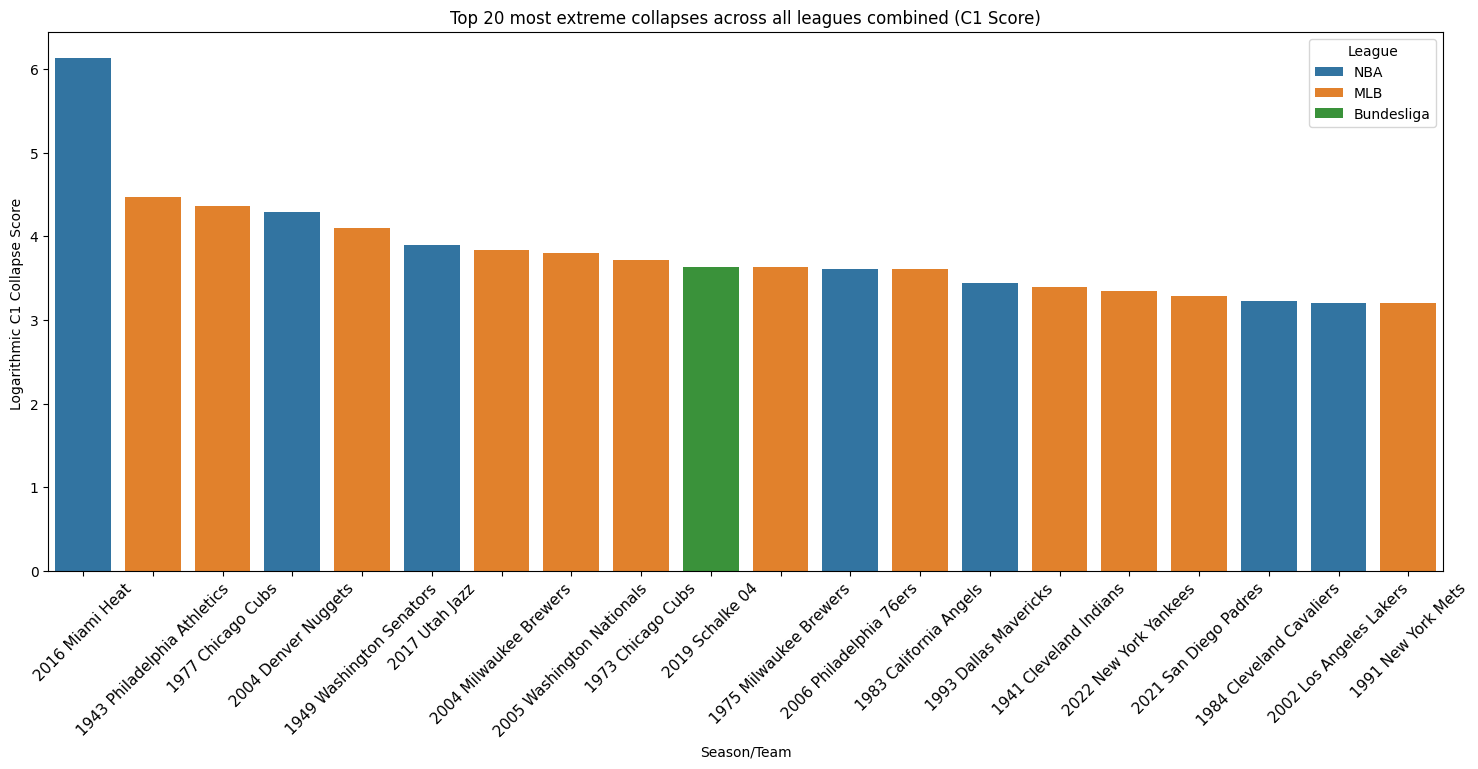

In [26]:
plt.figure(figsize=(18,7))

sns.barplot(x=combined__top20_c1['Team_Name'], y = combined__top20_c1['log_c1'], palette = 'tab10', hue = combined__top20_c1['League'])
plt.title('Top 20 most extreme collapses across all leagues combined (C1 Score)')
plt.xlabel('Season/Team')
plt.ylabel('Logarithmic C1 Collapse Score ')
plt.xticks(rotation=45, fontsize=11)
plt.show()

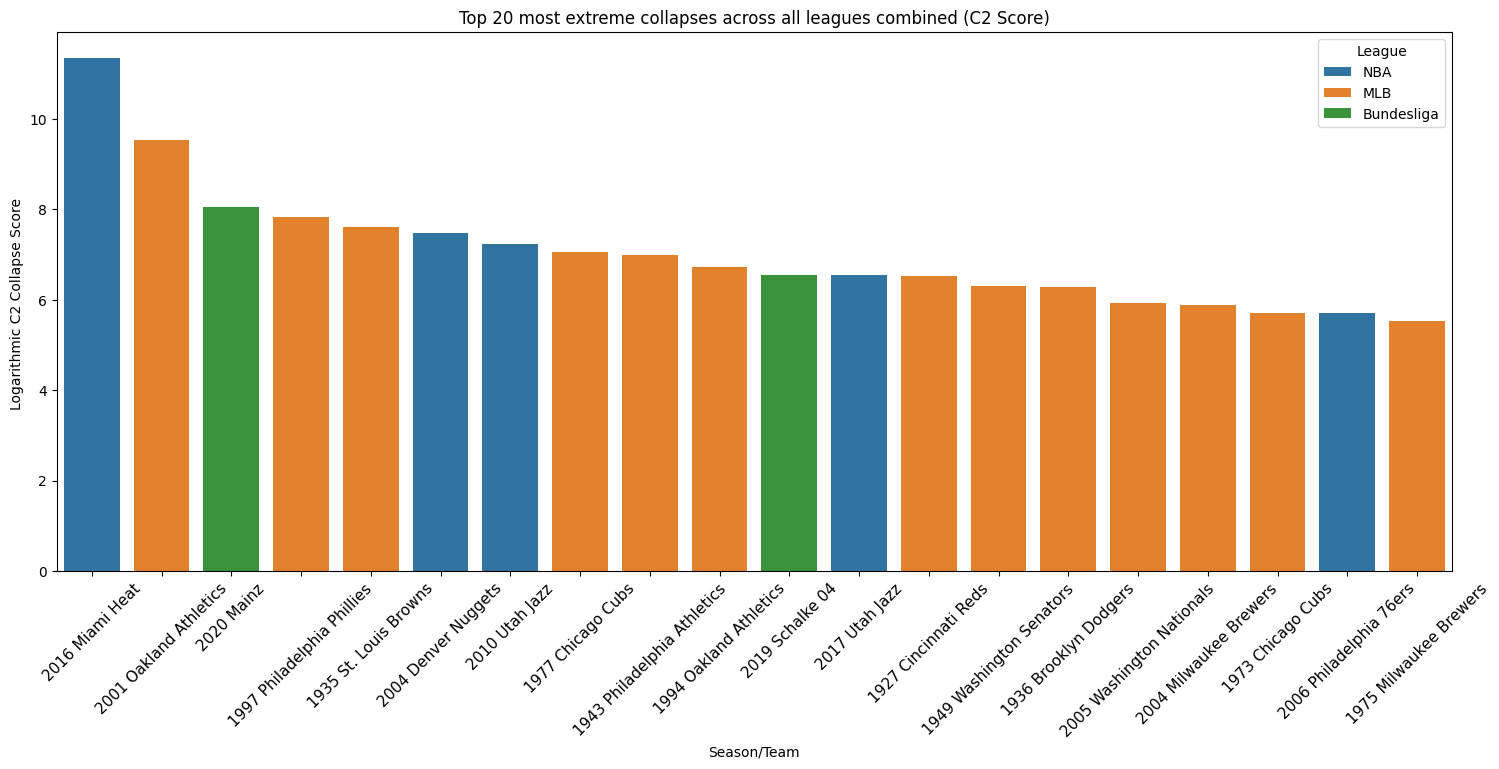

In [27]:
plt.figure(figsize=(18,7))

sns.barplot(x=combined__top20_c2['Team_Name'], y = combined__top20_c2['log_c2'], palette = 'tab10', hue = combined__top20_c2['League'])
plt.title('Top 20 most extreme collapses across all leagues combined (C2 Score)')
plt.xlabel('Season/Team')
plt.ylabel('Logarithmic C2 Collapse Score ')
plt.xticks(rotation=45, fontsize=11)
plt.show()

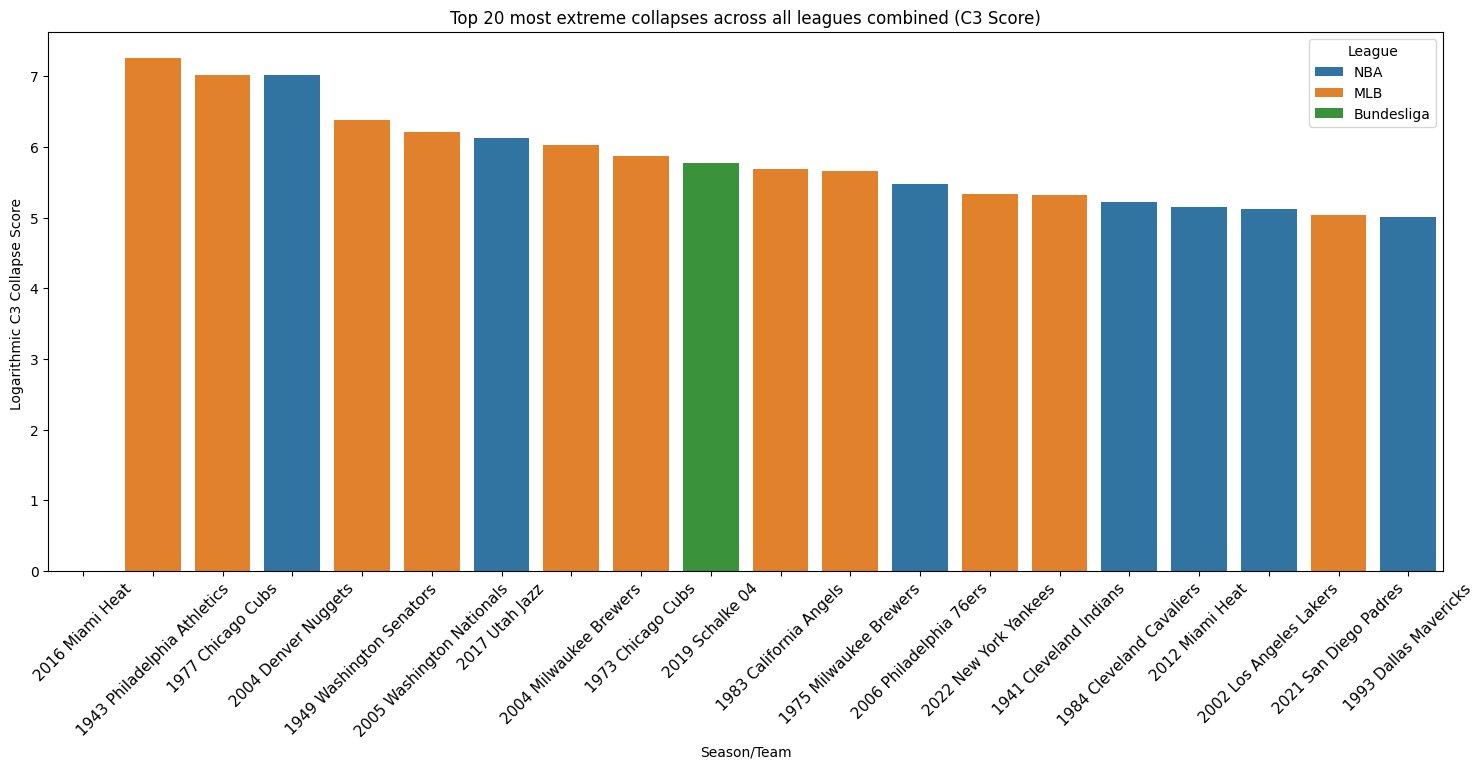

In [28]:
plt.figure(figsize=(18,7))

sns.barplot(x=combined__top20_c3['Team_Name'], y = combined__top20_c3['log_c3'], palette = 'tab10', hue = combined__top20_c3['League'])
plt.title('Top 20 most extreme collapses across all leagues combined (C3 Score)')
plt.xlabel('Season/Team')
plt.ylabel('Logarithmic C3 Collapse Score ')
plt.xticks(rotation=45, fontsize=11)
plt.show()

In [30]:
combined_df.sort_values('c1', ascending = False)

,Unnamed: 0,League,Season,Team,Sequence,n,n1,n2,k,k1,k2,c1,c2,c3,Team_Name,log_c1,log_c2,log_c3,formatted_team_name,color
3835,2397,NBA,2016,Miami Heat,"[1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, ...",82,41,41,41,30,11,462.534162,85959.498917,inf,2016 Miami Heat,6.136720,11.361632,inf,2016 Miami Heat,orange
1750,312,MLB,1943,Philadelphia Athletics,"[0,0,1,1,0,0,1,0,0,0,0,1,1,0,1,0,1,0,1,0,1,1,0...",154,77,77,49,34,15,87.788091,1097.891686,1428.571429,1943 Philadelphia Athletics,4.474926,7.001147,7.264430,1943 Philadelphia Athletics,blue
2383,945,MLB,1977,Chicago Cubs,"[0,0,1,1,1,1,0,0,0,0,1,1,1,0,0,0,1,1,0,1,1,1,1...",162,81,81,81,51,30,77.959464,1157.387002,1111.111111,1977 Chicago Cubs,4.356189,7.053920,7.013116,1977 Chicago Cubs,blue
4877,3439,NBA,2004,Denver Nuggets,"[1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, ...",82,41,41,49,32,17,73.182056,1767.544529,1111.111111,2004 Denver Nuggets,4.292950,7.477347,7.013116,2004 Denver Nuggets,orange
1851,413,MLB,1949,Washington Senators,"[1,0,0,0,0,0,0,0,1,0,0,1,0,0,1,1,1,1,1,1,1,1,1...",154,77,77,50,34,16,60.154303,552.611520,588.235294,1949 Washington Senators,4.096913,6.314655,6.377127,1949 Washington Senators,blue
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
596,596,Premier_League,2007,Chelsea,"[1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, ...",28,14,14,25,11,14,1.000000,12.154085,1.000000,2007 Chelsea,0.000000,2.497665,0.000000,NaN,NaN
537,537,Premier_League,2004,Chelsea,"[1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, ...",26,13,13,25,12,13,1.000000,2.966927,1.000000,2004 Chelsea,0.000000,1.087527,0.000000,NaN,NaN
424,424,Bundesliga,2023,Leverkusen,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",28,14,14,28,14,14,1.000000,NaN,1.000000,2023 Leverkusen,0.000000,NaN,0.000000,NaN,NaN
471,471,Premier_League,2001,Arsenal,"[1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, ...",29,15,14,26,12,14,1.000000,12.133290,1.000000,2001 Arsenal,0.000000,2.495953,0.000000,NaN,NaN
